In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
df=pd.read_csv("gym_members_exercise_tracking.csv")

In [6]:
df

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,1364,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883,HIIT,28.2,2.1,3,2,37.74


In [7]:
df.shape

(973, 15)

In [8]:
df.isnull().sum()

Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

In [9]:
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556,Strength,29.2,2.8,3,1,14.39


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    int64  
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

In [11]:
df["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [12]:
df["Gender"].value_counts()

Gender
Male      511
Female    462
Name: count, dtype: int64

In [13]:
df.rename(columns={"Weight (kg)":"Weight","Height (m)":"Height"},inplace=True)

In [14]:
max_weight = df.loc[df['Weight'].idxmax()]

In [15]:
max_weight   # overall max weight

Age                                 55
Gender                            Male
Weight                           129.9
Height                            1.73
Max_BPM                            187
Avg_BPM                            155
Resting_BPM                         60
Session_Duration (hours)          0.69
Calories_Burned                    529
Workout_Type                      Yoga
Fat_Percentage                    21.7
Water_Intake (liters)              3.1
Workout_Frequency (days/week)        3
Experience_Level                     1
BMI                               43.4
Name: 593, dtype: object

In [16]:
max_height = df.loc[df['Height'].idxmax()]

In [17]:
max_height   #overall max height

Age                                 41
Gender                            Male
Weight                            94.5
Height                             2.0
Max_BPM                            179
Avg_BPM                            136
Resting_BPM                         69
Session_Duration (hours)          1.18
Calories_Burned                    794
Workout_Type                      HIIT
Fat_Percentage                    27.6
Water_Intake (liters)              3.7
Workout_Frequency (days/week)        3
Experience_Level                     1
BMI                              23.62
Name: 13, dtype: object

In [18]:
df.groupby(["Gender","Workout_Type"])[["Calories_Burned"]].agg(["sum","max"])

Calories_Burned      
                                sum   max
Gender Workout_Type                      
Female Cardio                105184  1625
       HIIT                   93085  1474
       Strength              106161  1463
       Yoga                   93929  1582
Male   Cardio                120367  1515
       HIIT                  111518  1766
       Strength              128799  1783
       Yoga                  121933  1536

In [24]:
df.groupby("Gender")[["Weight","Height"]].agg(["min","max"])

Weight        Height     
          min    max    min  max
Gender                          
Female   40.0   79.9    1.5  1.8
Male     45.0  129.9    1.6  2.0

In [25]:
df1=df.sort_values(by="Age")

In [26]:
df1

,Age,Gender,Weight,Height,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
884,18,Male,114.5,1.97,192,128,60,1.03,725,Cardio,24.1,2.6,3,1,29.50
403,18,Female,67.4,1.60,182,164,71,0.60,492,Strength,33.5,2.4,3,1,26.33
687,18,Male,125.9,1.67,172,153,60,1.46,1229,Yoga,20.6,2.2,3,2,45.14
459,18,Male,62.0,1.85,161,121,53,0.88,586,Strength,23.7,3.0,3,1,18.12
242,18,Female,60.9,1.79,191,126,69,1.11,699,Cardio,31.1,2.1,2,1,19.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,59,Male,86.9,1.76,194,123,60,1.13,688,Strength,29.8,3.1,3,2,28.05
385,59,Female,42.1,1.65,172,132,59,1.22,725,Strength,33.0,2.2,2,1,15.46
128,59,Male,122.3,1.89,178,153,51,0.66,500,Yoga,20.1,3.1,3,1,34.24
729,59,Male,96.7,1.71,183,150,62,0.57,423,Yoga,28.4,2.9,3,1,33.07


In [27]:
#df1.groupby("Gender")[["Max_BPM","Avg_BPM","Resting_BPM"]].agg(["mean"])

In [4]:
# resting bpm
gender=input("enter gender:");

if gender.lower()=="male":
    age=int(input("enter the age:"));    
    if age >=19 and age<=39:
        print("the avg resting heart rate should between 69-75. if it more than 76 youve below avg and poor resting bpm")
    elif age >=40 and age <=59:
        print("the avg resting heart rate should between 68-76.if it more than 76 youve below avg and poor resting bpm")
    elif age>=60 and age <=79:
        print("the avg resting heart rate should between 67-76.if it more than 76 youve below avg and poor resting bpm")
else:
    age=int(input("enter the age"));
    if age >=19 and age<=39:
        print("the avg resting heart rate should between 74-81. if it more than 81 youve below avg and poor resting bpm")
    elif age >=40 and age <=59:
        print("the avg resting heart rate should between 71-78.if it more than 78 youve below avg and poor resting bpm")
    elif age>=60 and age <=79:
        print("the avg resting heart rate should between 70-77.if it more than 77 youve below avg and poor resting bpm")
        
    

enter gender: male
enter the age: 27


the avg resting heart rate should between 69-75. if it more than 76 youve below avg and poor resting bpm


In [67]:
#df1.groupby(["Gender","Workout_Type"])[["Calories_Burned"]].mean()

In [71]:
df1_corr=df1[["Calories_Burned","Session_Duration (hours)"]]

In [72]:
df1_corr.corr()

,Calories_Burned,Session_Duration (hours)
Calories_Burned,1.00000,0.90814
Session_Duration (hours),0.90814,1.00000


<Axes: xlabel='Session_Duration (hours)', ylabel='Calories_Burned'>

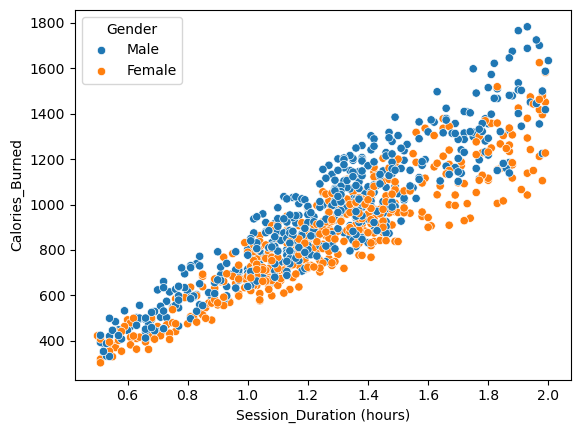

In [29]:
sns.scatterplot(x="Session_Duration (hours)",y="Calories_Burned", hue="Gender",data=df1)

In [30]:
df.columns

Index(['Age', 'Gender', 'Weight', 'Height', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI'],
      dtype='object')

In [31]:
df2_corr=df[["BMI","Weight"]]

In [32]:
df2_corr.corr()

,BMI,Weight
BMI,1.000000,0.853158
Weight,0.853158,1.000000


<Axes: xlabel='BMI', ylabel='Weight'>

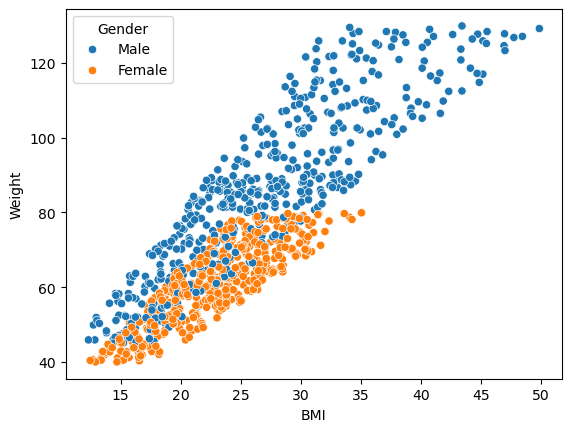

In [33]:
sns.scatterplot(x="BMI",y="Weight",data=df1, hue="Gender") #BMI-- body mass index.

#"Whether you have a healthy weight or are underweight, overweight, or obese "
#"Underweight: Less than 18.5. Recommended: 18.6 to 24.9. Overweight: 25.0 to 29.9. Obese: 30 or greater."

In [34]:
df3_corr=df1[["Workout_Frequency (days/week)","Experience_Level"]]

In [35]:
df3_corr.corr()

,Workout_Frequency (days/week),Experience_Level
Workout_Frequency (days/week),1.000000,0.837079
Experience_Level,0.837079,1.000000


<Axes: xlabel='Experience_Level', ylabel='Workout_Frequency (days/week)'>

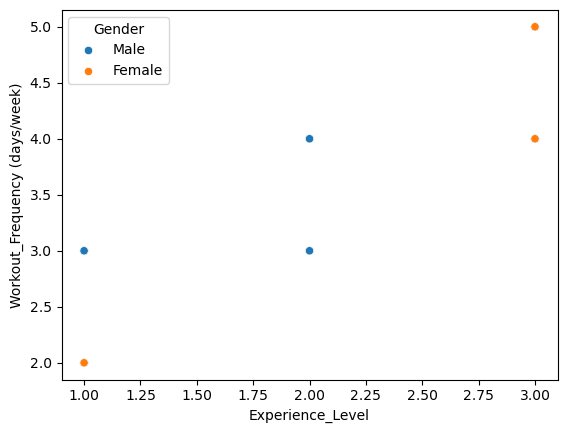

In [36]:
sns.scatterplot(x="Experience_Level",y="Workout_Frequency (days/week)",hue="Gender",data=df1)

In [37]:
df5_corr=df1[["Calories_Burned","Fat_Percentage"]]

In [38]:
df5_corr.corr()

,Calories_Burned,Fat_Percentage
Calories_Burned,1.000000,-0.597615
Fat_Percentage,-0.597615,1.000000


<Axes: xlabel='Calories_Burned', ylabel='Fat_Percentage'>

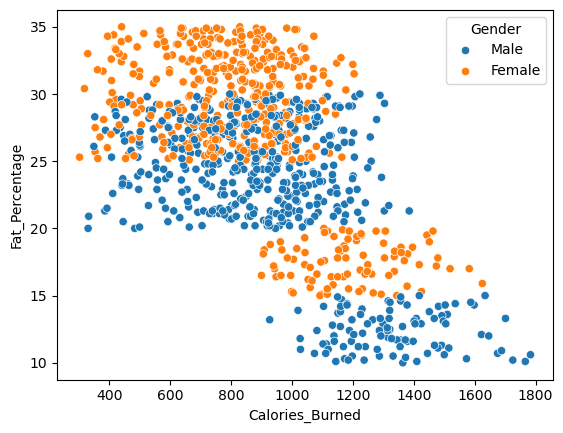

In [39]:
sns.scatterplot(x="Calories_Burned",y="Fat_Percentage",hue="Gender",data=df1)

In [40]:
df7_corr=df1[["Fat_Percentage","Session_Duration (hours)"]]

In [41]:
df7_corr.corr()

,Fat_Percentage,Session_Duration (hours)
Fat_Percentage,1.00000,-0.58152
Session_Duration (hours),-0.58152,1.00000


<Axes: xlabel='Session_Duration (hours)', ylabel='Fat_Percentage'>

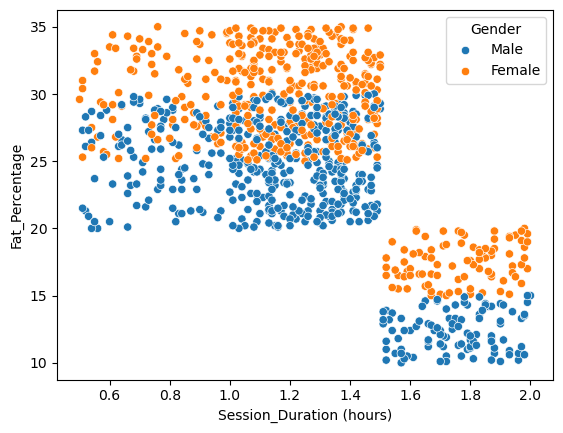

In [42]:
sns.scatterplot(x="Session_Duration (hours)",y="Fat_Percentage",hue="Gender",data=df1)

In [43]:
 df.columns


Index(['Age', 'Gender', 'Weight', 'Height', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI'],
      dtype='object')

<Axes: xlabel='Height', ylabel='Count'>

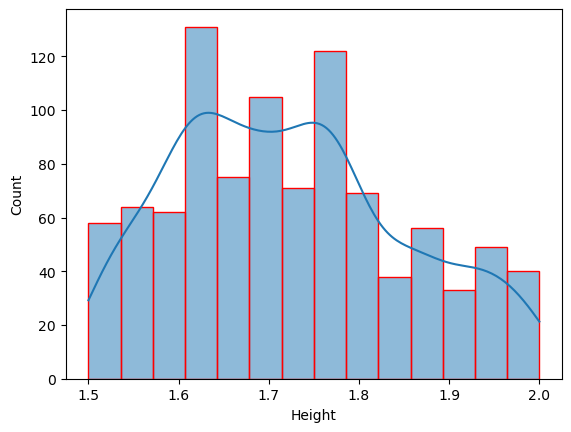

In [44]:
sns.histplot(x="Height",data=df1,kde=True,edgecolor="red")

<Axes: xlabel='Height', ylabel='Count'>

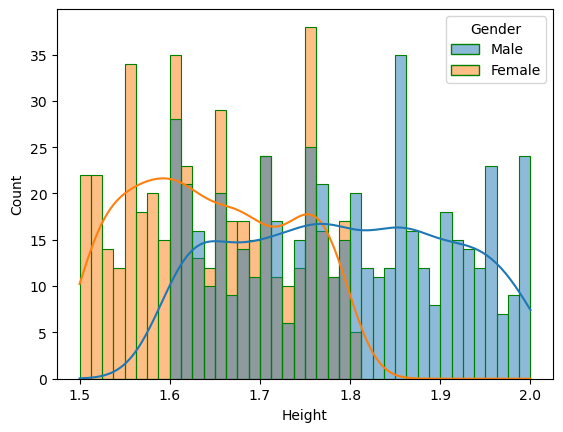

In [45]:
sns.histplot(x="Height",data=df1,kde=True,hue="Gender",bins=40,edgecolor="green")

<Axes: xlabel='Height'>

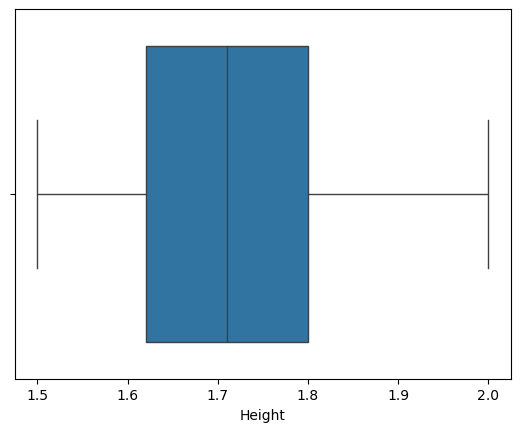

In [46]:
sns.boxplot(x=df["Height"])

<Axes: xlabel='Weight', ylabel='Count'>

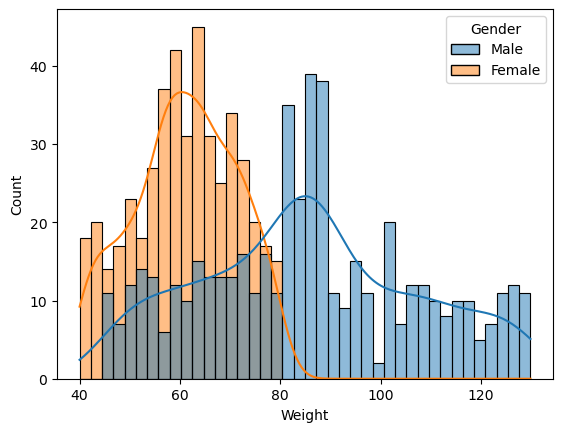

In [47]:
sns.histplot(x="Weight",data=df1,kde=True,hue="Gender",bins=40)

<Axes: xlabel='Weight'>

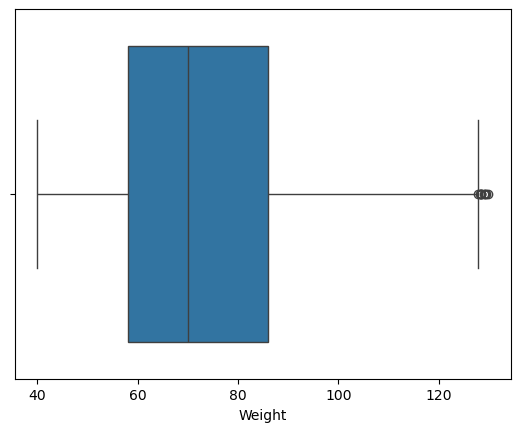

In [48]:
sns.boxplot(x=df["Weight"])

In [49]:
def replace_outliers(df,column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)

    IQR=Q3-Q1

    upper_bound=Q3+1.5*IQR  
    lower_bound=Q1-1.5*IQR

    # capping-replacing all higher values with upper bound (75% percentile)
    df[column]=np.where(df[column]>upper_bound,upper_bound,df[column])
    # flooring -replace all lower values with lower bound (25% percentile)
    df[column]=np.where(df[column]<lower_bound,lower_bound,df[column])

In [50]:
replace_outliers(df,"Weight")

In [51]:
df

,Age,Gender,Weight,Height,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,1364,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883,HIIT,28.2,2.1,3,2,37.74


<Axes: xlabel='Weight'>

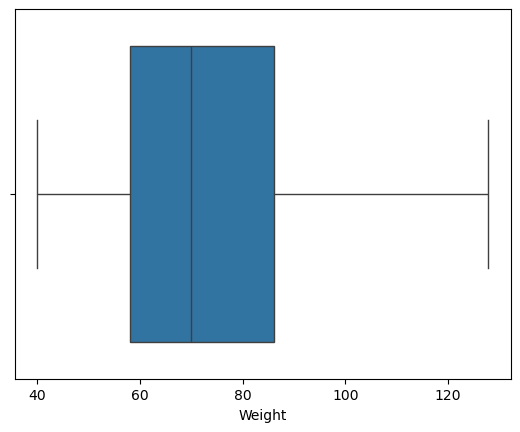

In [52]:
sns.boxplot(x=df["Weight"])

In [53]:
df.head()

,Age,Gender,Weight,Height,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556,Strength,29.2,2.8,3,1,14.39


In [54]:
df.columns

Index(['Age', 'Gender', 'Weight', 'Height', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI'],
      dtype='object')

<Axes: xlabel='Workout_Type', ylabel='Calories_Burned'>

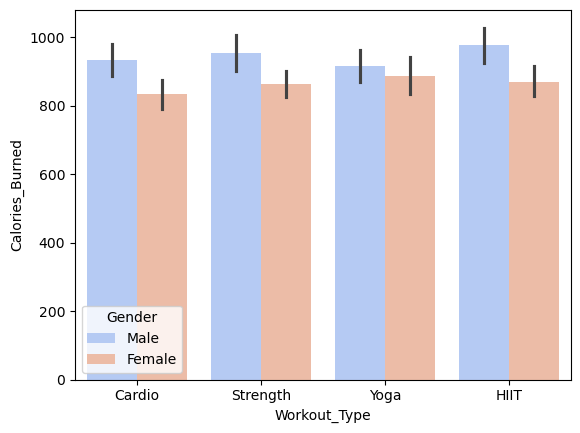

In [55]:
sns.barplot(x="Workout_Type",y="Calories_Burned",hue="Gender",data=df1,palette="coolwarm")


<Axes: xlabel='Gender', ylabel='count'>

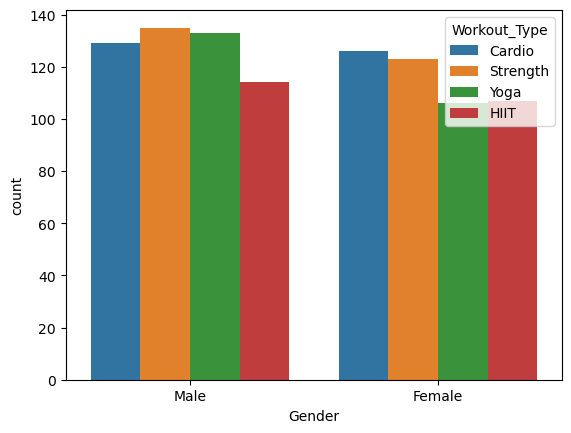

In [56]:
sns.countplot(x="Gender",hue="Workout_Type",data=df1)


In [57]:
dff=df[["Workout_Type","Fat_Percentage"]].head(4)
dff

,Workout_Type,Fat_Percentage
0,Yoga,12.6
1,HIIT,33.9
2,Cardio,33.4
3,Strength,28.8


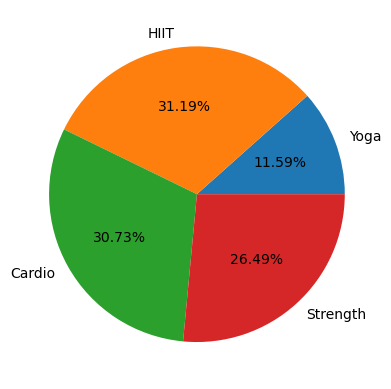

In [58]:
plt.pie(dff["Fat_Percentage"],labels=dff["Workout_Type"],autopct="%.2f%%")
plt.show()

<Axes: xlabel='Max_BPM', ylabel='Count'>

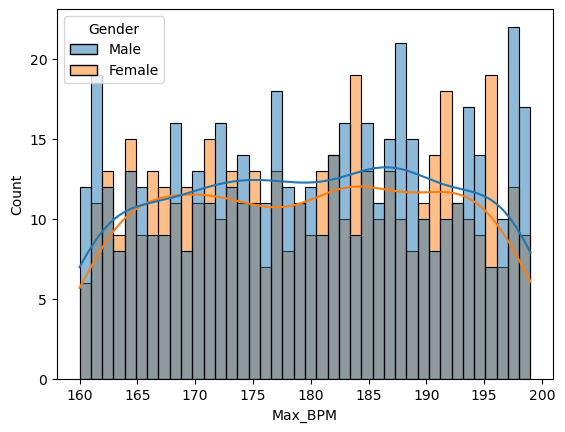

In [59]:
sns.histplot(x="Max_BPM",data=df1,kde=True,hue="Gender",bins=40)

<Axes: xlabel='Max_BPM'>

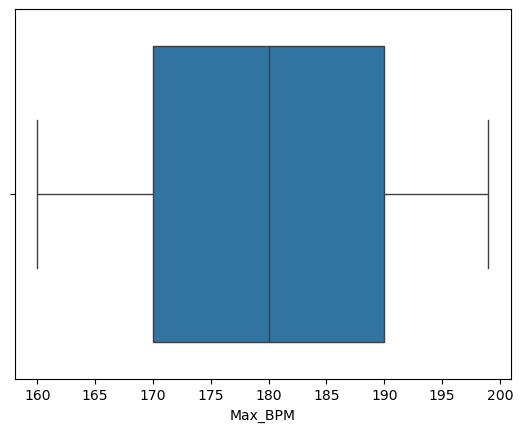

In [60]:
sns.boxplot(x=df["Max_BPM"])

<Axes: xlabel='Calories_Burned', ylabel='Count'>

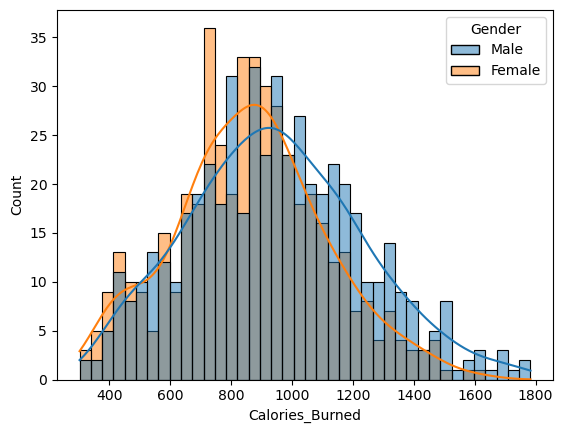

In [61]:
sns.histplot(x="Calories_Burned",data=df1,kde=True,hue="Gender",bins=40)

<Axes: xlabel='Calories_Burned'>

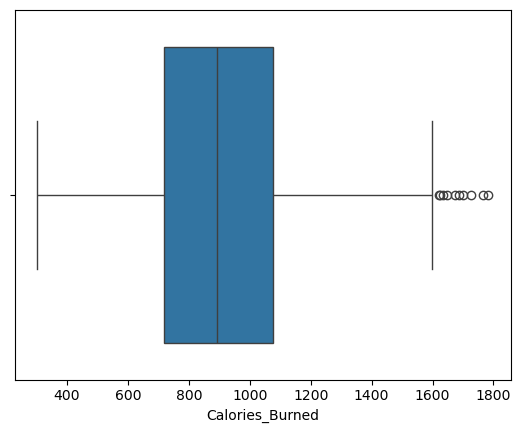

In [62]:
sns.boxplot(x=df["Calories_Burned"])

In [63]:
replace_outliers(df,"Calories_Burned")

<Axes: xlabel='Calories_Burned'>

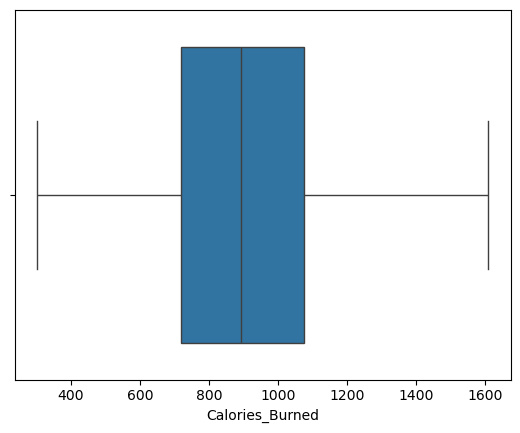

In [64]:
sns.boxplot(x=df["Calories_Burned"])

<Axes: xlabel='Fat_Percentage', ylabel='Count'>

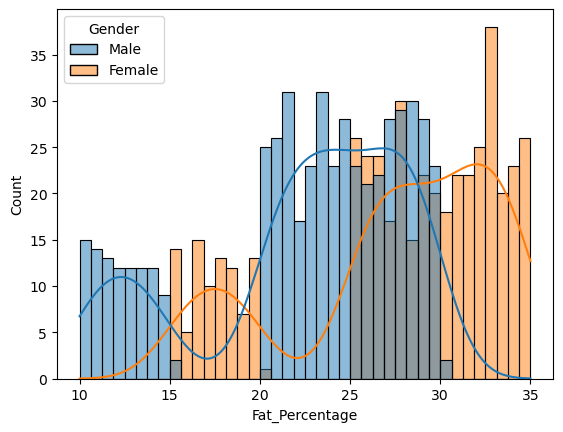

In [65]:
sns.histplot(x="Fat_Percentage",data=df,hue="Gender",bins=40,kde=True)

<Axes: xlabel='Fat_Percentage'>

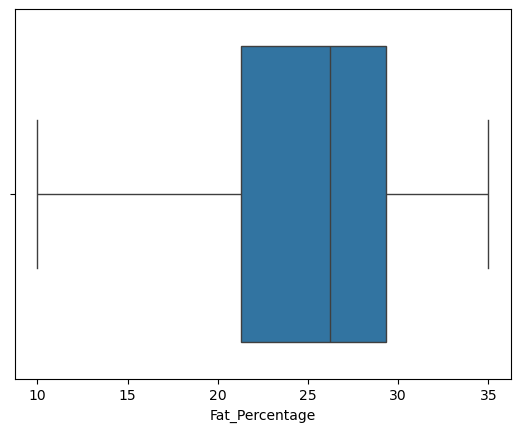

In [66]:
sns.boxplot(x=df["Fat_Percentage"])